# 알고리즘 기말 프로젝트 — 가산 A

## EDC-likeness Score Function Design

- **제출일**: `<YYYY.MM.DD HH:MM>`
- **파일명**: `이름_학번_EDC_bonus.ipynb`
- **사용 데이터**: `C:\Users\DS\AL\project\PubChem_EDC.csv`
- **비교 데이터**: `C:\Users\DS\AL\project\PubChem_Drug.csv`
- **목표**: Pesticide 외 추가 화학 제품군/관심군인 EDC(Endocrine Disrupting Chemicals)에 대해 별도의 explainable score function을 만들고 평가한다.

## 학번 / 이름

- **학번**: `          `
- **이름**: `          `
- **score에 대한 간략한 설명**: EDC reference set을 기준으로 physicochemical property, Murcko scaffold, fingerprint similarity, SMARTS fragment enrichment를 결합하여 EDC-likeness를 계산하는 explainable score.


## 가산 A 요구사항

Pesticide 외에 다른 1종 이상의 카테고리(cosmetic / food additive / fragrance / surfactant / dye / EDC 등)에 대해 같은 절차로 score 함수를 만들고 평가한다.

이 노트북에서는 EDC 데이터를 positive set으로 사용한다.

- Positive set: `PubChem_EDC.csv`
- Negative/comparison set: `PubChem_Drug.csv`
- 평가 방식: EDC vs Drug score distribution, ROC-AUC, PR curve, top-hit explanation
- 설계 원칙: black-box classifier가 아니라 왜 EDC-like인지 설명 가능한 score function


---
# Task 1. Negative 데이터 준비

**문제**: EDC positive 분자와 구조적으로 다른 비교군을 어떻게 만들 것인가?

## 📝 본인 선택과 이유

- 선택한 기준: `PubChem_EDC.csv`를 positive set으로 사용하고, `PubChem_Drug.csv`를 comparison/negative set으로 사용한다.
- 이유: EDC는 독성/내분비계 교란 가능성과 관련된 화학물질 집합이고, drug set은 생리활성 small molecule이지만 EDC 용도 또는 위험성 annotation과는 다른 비교군이다. 따라서 drug comparison을 사용하면 단순히 bioactive molecule을 찾는 것이 아니라 EDC-like property, scaffold, fragment signature를 구분하는지 평가할 수 있다.

## 구조 유사도 기준

- Morgan fingerprint, RDKit fingerprint, MACCS keys를 사용한다.
- 각 drug 분자와 EDC reference set 사이의 maximum Tanimoto similarity를 계산한다.
- Drug set 중 EDC와 similarity가 매우 높은 분자는 EDC-like chemical space와 겹칠 수 있으므로 해석에서 주의한다.
- 최종 평가는 hard threshold 하나가 아니라 property, scaffold, similarity, fragment score를 결합한 final score distribution으로 수행한다.


In [1]:
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

In [2]:
from pathlib import Path
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None

from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors, MACCSkeys
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import Draw

try:
    from sklearn.neighbors import KernelDensity
    from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
    SKLEARN_OK = True
except Exception:
    SKLEARN_OK = False

BASE = Path(r"C:\Users\DS\AL\project")
EDC_PATH = BASE / "PubChem_EDC.csv"
DRUG_PATH = BASE / "PubChem_Drug.csv"

RANDOM_SEED = 42
MAX_EDC = 5000
MAX_DRUG = 5000
EPS = 1e-9

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)


In [3]:
def pick_col(df, candidates):
    lower = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    return None

def load_pubchem_csv(path, label, max_rows=None):
    df = pd.read_csv(path)
    smi_col = pick_col(df, ["SMILES", "smiles", "CanonicalSMILES", "canonical_smiles"])
    name_col = pick_col(df, ["Name", "cmpdname", "IUPAC_Name", "iupacname"])
    cid_col = pick_col(df, ["Compound_CID", "cid", "CID"])
    if smi_col is None:
        raise ValueError(f"SMILES column not found in {path}")
    out = pd.DataFrame({
        "source": label,
        "smiles": df[smi_col].astype(str),
        "name": df[name_col].astype(str) if name_col else "",
        "cid": df[cid_col].astype(str) if cid_col else "",
    })
    out = out[out["smiles"].notna() & (out["smiles"] != "nan")].drop_duplicates("smiles")
    if max_rows and len(out) > max_rows:
        out = out.sample(max_rows, random_state=RANDOM_SEED)
    return out.reset_index(drop=True)

def mol_from_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        return mol
    except Exception:
        return None

def clean_molecules(df):
    df = df.copy()
    df["mol"] = df["smiles"].map(mol_from_smiles)
    df = df[df["mol"].notna()].copy()
    df["canonical_smiles"] = df["mol"].map(lambda m: Chem.MolToSmiles(m, isomericSmiles=True))
    df = df.drop_duplicates("canonical_smiles").reset_index(drop=True)
    return df

edc = clean_molecules(load_pubchem_csv(EDC_PATH, "EDC", MAX_EDC))
drug = clean_molecules(load_pubchem_csv(DRUG_PATH, "Drug", MAX_DRUG))

print("EDC:", edc.shape)
print("Drug:", drug.shape)
display(pd.concat([edc.head(3), drug.head(3)]))


EDC: (5000, 6)
Drug: (5000, 6)


,source,smiles,name,cid,mol,canonical_smiles
0,EDC,CC(C)(C1=CC=CC=C1)C2=CC(=C(C(=C2)C(C)(C)C3=CC=...,"2,2'-Methylenebis[4,6-bis(1-methyl-1-phenyleth...",117014,<rdkit.Chem.rdchem.Mol object at 0x000001F8CE4...,CC(C)(c1ccccc1)c1cc(Cc2cc(C(C)(C)c3ccccc3)cc(C...
1,EDC,C1=CC(=C(C=C1Cl)C2=CC(=C(C(=C2Cl)Cl)Cl)Cl)Cl,"2,2',3,4,5,5'-Hexachlorobiphenyl",40234,<rdkit.Chem.rdchem.Mol object at 0x000001F8CE4...,Clc1ccc(Cl)c(-c2cc(Cl)c(Cl)c(Cl)c2Cl)c1
2,EDC,CC1=C2C=C(CC[C@@]2([C@H]3CC[C@]4([C@H]([C@@H]3...,"17-Hydroxy-3-methoxy-6-methylpregna-3,5-dien-2...",101969,<rdkit.Chem.rdchem.Mol object at 0x000001F8CE4...,COC1=CC2=C(C)C[C@@H]3[C@H](CC[C@@]4(C)[C@H]3CC...
0,Drug,C1[C@@H](O[C@@H](O1)CO)N2C=NC3=C(N=C(N=C32)N)N,Amdoxovir,124088,<rdkit.Chem.rdchem.Mol object at 0x000001F8CEA...,Nc1nc(N)c2ncn([C@H]3CO[C@@H](CO)O3)c2n1
1,Drug,CCC1=C(NC2=C1C(=O)[C@@H](CC2)CN3CCOCC3)C,"Molindone, (S)-",6604347,<rdkit.Chem.rdchem.Mol object at 0x000001F8CEA...,CCc1c(C)[nH]c2c1C(=O)[C@H](CN1CCOCC1)CC2
2,Drug,C(CO)NC(=O)C(=O)O,Hydroxyethyloxamic acid,165301,<rdkit.Chem.rdchem.Mol object at 0x000001F8CEA...,O=C(O)C(=O)NCCO


---
# Task 2. Score 함수 설계

**문제**: EDC-likeness 점수를 계산하는 함수 개발.

EDC score는 다음 네 요소를 결합한다.

1. **Property score**: EDC reference distribution에 가까운 physicochemical property인지 평가
2. **Scaffold score**: EDC set에서 enriched된 Murcko scaffold인지 평가
3. **Similarity score**: EDC reference와 fingerprint Tanimoto similarity가 높은지 평가
4. **Fragment score**: EDC 관련 가능성이 있는 SMARTS fragment가 enriched되어 있는지 평가

최종 결합은 weighted geometric mean을 사용한다.

```text
Final EDC score = exp(sum(w_i * log(score_i + eps)) / sum(w_i))
```

기본 가중치:

- property_score: 0.30
- scaffold_score: 0.20
- similarity_score: 0.30
- fragment_score: 0.20

Geometric mean을 사용하는 이유는 하나의 근거만 높은 분자가 과도하게 높은 최종 점수를 받는 것을 막기 위해서다. EDC-like 후보는 property, scaffold, similarity, fragment 근거가 함께 높아야 한다.


MW                                                          \
         count    mean     std    min     25%     50%     75%      max   
source                                                                   
Drug    5000.0  410.28  367.62  11.01  260.17  349.89  458.51  7594.91   
EDC     5000.0  360.76  169.46  10.81  256.25  326.44  418.21  1701.21   

          LogP        ... HeavyAtoms        AromaticRings                   \
         count  mean  ...        75%    max         count  mean   std  min   
source                ...                                                    
Drug    5000.0  1.84  ...       32.0  492.0        5000.0  1.66  1.42  0.0   
EDC     5000.0  4.28  ...       29.0  122.0        5000.0  1.54  1.28  0.0   

                             
        25%  50%  75%   max  
source                       
Drug    1.0  2.0  2.0  26.0  
EDC     1.0  1.0  2.0  12.0  

[2 rows x 64 columns]

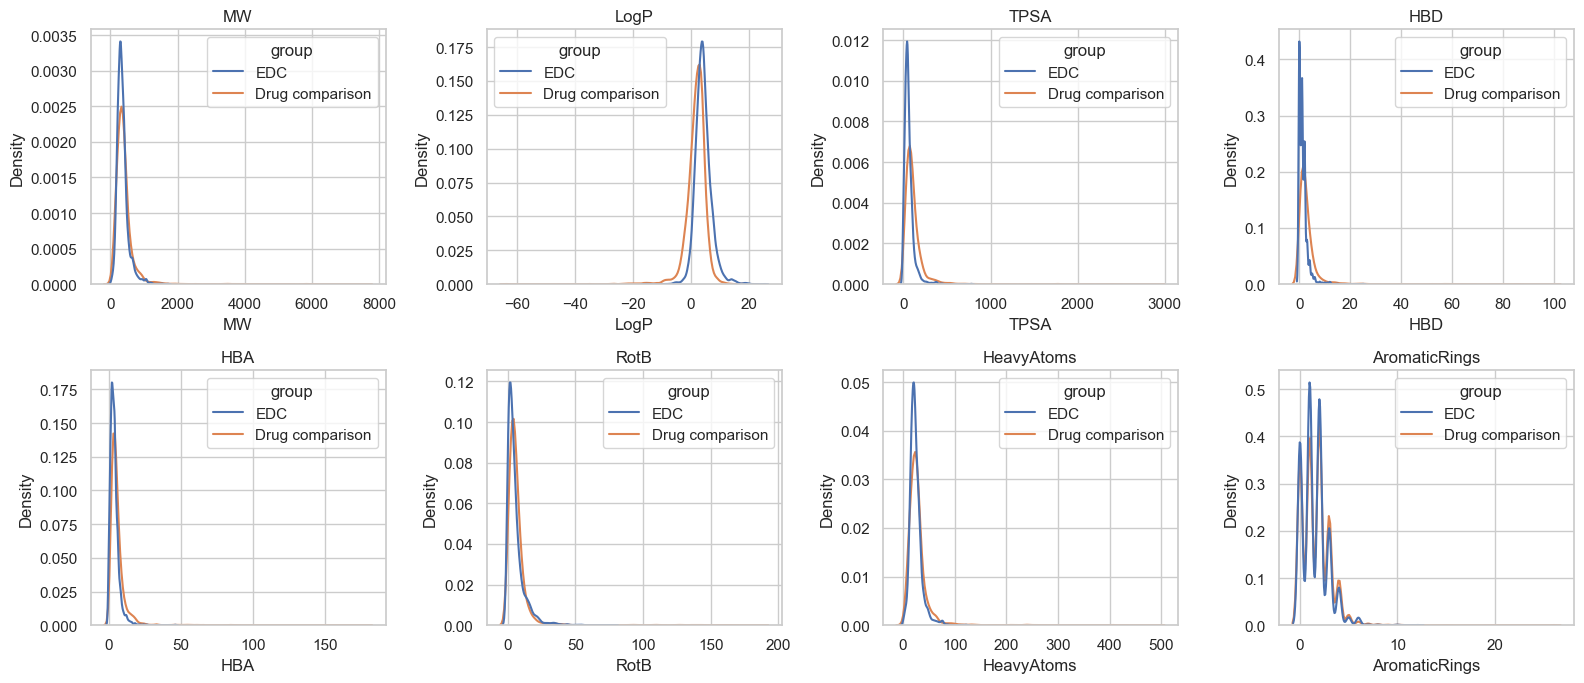

In [4]:
def calc_descriptors(mol):
    return {
        "MW": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "RotB": Lipinski.NumRotatableBonds(mol),
        "HeavyAtoms": mol.GetNumHeavyAtoms(),
        "AromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol),
    }

def add_descriptors(df):
    desc = pd.DataFrame([calc_descriptors(m) for m in df["mol"]])
    return pd.concat([df.reset_index(drop=True), desc], axis=1)

edc = add_descriptors(edc)
drug = add_descriptors(drug)
desc_cols = ["MW", "LogP", "TPSA", "HBD", "HBA", "RotB", "HeavyAtoms", "AromaticRings"]

display(pd.concat([edc, drug]).groupby("source")[desc_cols].describe().round(2))

plot_df = pd.concat([edc.assign(group="EDC"), drug.assign(group="Drug comparison")])
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), desc_cols):
    if sns:
        sns.kdeplot(data=plot_df, x=col, hue="group", common_norm=False, ax=ax, warn_singular=False)
    else:
        for group, part in plot_df.groupby("group"):
            ax.hist(part[col].dropna(), bins=40, alpha=0.35, density=True, label=group)
        ax.legend(fontsize=8)
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [5]:
def gaussian_desirability(values, ref_values):
    ref = pd.Series(ref_values).dropna().astype(float)
    mu, sd = ref.mean(), ref.std()
    if not np.isfinite(sd) or sd < EPS:
        sd = 1.0
    z = (pd.Series(values).astype(float) - mu) / sd
    return np.exp(-0.5 * z * z).clip(EPS, 1.0)

def kde_desirability(values, ref_values):
    if not SKLEARN_OK:
        return gaussian_desirability(values, ref_values)
    ref = pd.Series(ref_values).dropna().astype(float).values.reshape(-1, 1)
    val = pd.Series(values).astype(float).values.reshape(-1, 1)
    if len(ref) < 30 or np.std(ref) < EPS:
        return gaussian_desirability(values, ref_values)
    bandwidth = max(0.05, 0.25 * np.std(ref))
    kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth).fit(ref)
    log_dens = kde.score_samples(val)
    ref_log_dens = kde.score_samples(ref)
    scaled = np.exp(log_dens - np.percentile(ref_log_dens, 95))
    return pd.Series(np.clip(scaled, EPS, 1.0))

def weighted_geometric_mean(score_frame, weights):
    cols = list(weights.keys())
    w = np.array([weights[c] for c in cols], dtype=float)
    w = w / w.sum()
    x = score_frame[cols].clip(EPS, 1.0).values
    return np.exp(np.dot(np.log(x), w))

property_weights = {"MW": 1.0, "LogP": 1.2, "TPSA": 1.0, "HBD": 0.8, "HBA": 0.8, "RotB": 0.8, "AromaticRings": 1.0}

def add_property_score(target, reference):
    target = target.copy()
    score_parts = {}
    for col in property_weights:
        score_parts[f"prop_{col}"] = kde_desirability(target[col], reference[col]).values
    part_df = pd.DataFrame(score_parts)
    weights = {f"prop_{k}": v for k, v in property_weights.items()}
    target["property_score"] = weighted_geometric_mean(part_df, weights)
    return pd.concat([target.reset_index(drop=True), part_df], axis=1)

edc = add_property_score(edc, edc)
drug = add_property_score(drug, edc)


In [6]:
def murcko_smiles(mol):
    try:
        scaf = MurckoScaffold.GetScaffoldForMol(mol)
        if scaf is None or scaf.GetNumAtoms() == 0:
            return ""
        return Chem.MolToSmiles(scaf, isomericSmiles=False)
    except Exception:
        return ""

for df in [edc, drug]:
    df["scaffold"] = df["mol"].map(murcko_smiles)

edc_scaf = edc["scaffold"].value_counts()
drug_scaf = drug["scaffold"].value_counts()
scaffold_table = pd.DataFrame({"edc_count": edc_scaf, "drug_count": drug_scaf}).fillna(0)
scaffold_table = scaffold_table[scaffold_table.index != ""]
scaffold_table["edc_freq"] = scaffold_table["edc_count"] / max(1, len(edc))
scaffold_table["drug_freq"] = scaffold_table["drug_count"] / max(1, len(drug))
scaffold_table["log_enrichment"] = np.log2((scaffold_table["edc_freq"] + EPS) / (scaffold_table["drug_freq"] + EPS))
scaffold_table["scaffold_score_ref"] = (
    np.log1p(scaffold_table["edc_count"]) / np.log1p(scaffold_table["edc_count"].max())
) * (1 / (1 + np.exp(-scaffold_table["log_enrichment"])))
scaffold_table = scaffold_table.sort_values(["scaffold_score_ref", "edc_count"], ascending=False)

def assign_scaffold_score(df):
    df = df.copy()
    score_map = scaffold_table["scaffold_score_ref"].to_dict()
    df["scaffold_score"] = df["scaffold"].map(score_map).fillna(0.05)
    df.loc[df["scaffold"] == "", "scaffold_score"] = 0.02
    return df

edc = assign_scaffold_score(edc)
drug = assign_scaffold_score(drug)
display(scaffold_table.head(20))


,edc_count,drug_count,edc_freq,drug_freq,log_enrichment,scaffold_score_ref
scaffold,,,,,,
c1ccc(Cc2ccccc2)cc1,204.0,27.0,0.0408,0.0054,2.917538,0.745847
c1ccc(-c2ccccc2)cc1,178.0,20.0,0.0356,0.0040,3.153805,0.734775
c1ccccc1,871.0,447.0,0.1742,0.0894,0.962398,0.723602
C1=C2CCCCC2C2CCC3CCCC3C2C1,54.0,3.0,0.0108,0.0006,4.169923,0.582849
O=C1C=C2CCC3C4CCCC4CCC3C2CC1,110.0,37.0,0.0220,0.0074,1.571906,0.575967
O=c1cc(-c2ccccc2)oc2ccccc12,48.0,2.0,0.0096,0.0004,4.584959,0.568990
O=C(c1ccccc1)c1ccccc1,46.0,4.0,0.0092,0.0008,3.523560,0.552350
c1ccc(Oc2ccccc2)cc1,56.0,12.0,0.0112,0.0024,2.222392,0.538757
c1ccc2c(c1)CCC1C2CCC2CCCC21,46.0,9.0,0.0092,0.0018,2.353636,0.519296


In [7]:
def fingerprint(mol, kind="morgan"):
    if kind == "morgan":
        return rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    if kind == "rdkit":
        return Chem.RDKFingerprint(mol)
    if kind == "maccs":
        return MACCSkeys.GenMACCSKeys(mol)
    raise ValueError(kind)

def max_tanimoto_to_reference(query_fps, ref_fps):
    scores = []
    for fp in query_fps:
        sims = DataStructs.BulkTanimotoSimilarity(fp, ref_fps)
        scores.append(max(sims) if sims else 0.0)
    return np.array(scores)

def add_similarity_score(target, reference, kind="morgan", ref_limit=2000):
    target = target.copy()
    ref = reference.sample(min(ref_limit, len(reference)), random_state=RANDOM_SEED) if len(reference) > ref_limit else reference
    ref_fps = [fingerprint(m, kind) for m in ref["mol"]]
    target_fps = [fingerprint(m, kind) for m in target["mol"]]
    target[f"sim_{kind}"] = max_tanimoto_to_reference(target_fps, ref_fps)
    return target

for kind in ["morgan", "rdkit", "maccs"]:
    edc = add_similarity_score(edc, edc, kind=kind)
    drug = add_similarity_score(drug, edc, kind=kind)

for df in [edc, drug]:
    df["similarity_score"] = df[["sim_morgan", "sim_rdkit", "sim_maccs"]].mean(axis=1).clip(EPS, 1.0)


In [8]:
SMARTS_LIBRARY = {
    "phenol": "c[OH]",
    "bisphenol_like": "c(O)ccc(*)cc1",
    "halogenated_aromatic": "c[F,Cl,Br,I]",
    "nitro_aromatic": "c[N+](=O)[O-]",
    "aniline": "c[NH2]",
    "amide": "C(=O)N",
    "urea": "NC(=O)N",
    "carbamate": "OC(=O)N",
    "ester": "C(=O)O",
    "phosphate": "P(=O)(O)(O)",
    "sulfone_sulfonamide": "S(=O)(=O)",
    "nitrile": "C#N",
    "pyridine": "n1ccccc1",
    "azole": "[nH,n]1cccc1",
}
SMARTS_MOLS = {name: Chem.MolFromSmarts(sma) for name, sma in SMARTS_LIBRARY.items()}
SMARTS_MOLS = {k: v for k, v in SMARTS_MOLS.items() if v is not None}

def add_fragment_flags(df):
    df = df.copy()
    for name, patt in SMARTS_MOLS.items():
        df[f"frag_{name}"] = df["mol"].map(lambda m: int(m.HasSubstructMatch(patt)))
    return df

edc = add_fragment_flags(edc)
drug = add_fragment_flags(drug)
frag_cols = [c for c in edc.columns if c.startswith("frag_")]

def enrichment_table(pos, neg, frag_cols):
    rows = []
    for col in frag_cols:
        a = int(pos[col].sum())
        b = int(len(pos) - a)
        c = int(neg[col].sum())
        d = int(len(neg) - c)
        odds = ((a + 0.5) / (b + 0.5)) / ((c + 0.5) / (d + 0.5))
        rows.append({
            "fragment": col.replace("frag_", ""),
            "edc_rate": a / max(1, len(pos)),
            "drug_rate": c / max(1, len(neg)),
            "odds_ratio": odds,
            "log2_enrichment": np.log2(odds),
            "edc_count": a,
            "drug_count": c,
        })
    return pd.DataFrame(rows).sort_values("log2_enrichment", ascending=False)

frag_enrich = enrichment_table(edc, drug, frag_cols)
display(frag_enrich)

enrich_map = frag_enrich.set_index("fragment")["log2_enrichment"].clip(lower=0).to_dict()

def add_fragment_score(df):
    df = df.copy()
    raw_scores = []
    hit_names = []
    for _, row in df.iterrows():
        total = 0.0
        hits = []
        for col in frag_cols:
            frag = col.replace("frag_", "")
            if row[col] == 1:
                total += 1.0 + enrich_map.get(frag, 0.0)
                hits.append(frag)
        raw_scores.append(total)
        hit_names.append(", ".join(hits))
    df["fragment_hits"] = hit_names
    df["fragment_score"] = (1 - np.exp(-np.array(raw_scores) / 3.0)).clip(0.02, 1.0)
    return df

edc = add_fragment_score(edc)
drug = add_fragment_score(drug)


,fragment,edc_rate,drug_rate,odds_ratio,log2_enrichment,edc_count,drug_count
0,phenol,0.3322,0.1276,3.399331,1.765251,1661,638
2,nitro_aromatic,0.0230,0.0192,1.201546,0.264892,115,96
1,halogenated_aromatic,0.1518,0.2018,0.708008,-0.498163,759,1009
7,ester,0.2886,0.3680,0.696774,-0.521238,1443,1840
10,nitrile,0.0162,0.0284,0.564838,-0.824091,81,142
3,aniline,0.0318,0.0844,0.357007,-1.485974,159,422
9,sulfone_sulfonamide,0.0356,0.0990,0.336562,-1.571055,178,495
6,carbamate,0.0074,0.0304,0.240204,-2.057666,37,152
4,amide,0.1106,0.3538,0.227277,-2.137477,553,1769
8,phosphate,0.0128,0.0596,0.205838,-2.280420,64,298


## 📝 Score 함수 설계 근거

EDC-likeness는 하나의 독성 alert로 결정하지 않는다. EDC 후보는 hormone-like interaction, hydrophobic aromatic motif, halogenated aromatic motif, phenolic motif, heteroatom-containing functional group 등 여러 구조적 특징이 동시에 나타날 수 있다.

따라서 본 score는 다음 근거를 조합한다.

- **Property:** receptor binding 또는 membrane partitioning과 관련될 수 있는 LogP, TPSA, MW, HBD/HBA 분포를 반영한다.
- **Scaffold:** EDC reference에서 반복되는 core scaffold를 찾는다.
- **Similarity:** 알려진 EDC와 fingerprint 기준으로 가까운 분자를 찾는다.
- **Fragment:** phenol, halogenated aromatic, nitro aromatic 등 설명 가능한 SMARTS alert를 반영한다.

Drug comparison set에도 bioactive motif는 존재하므로, 단순 fragment hit가 아니라 EDC vs drug enrichment를 반영한다.


---
# Task 3. Score 평가 — Goodness of the score

**문제**: 만든 EDC score 함수가 EDC positive와 drug comparison을 얼마나 잘 구분하는가?

평가는 다음 기준으로 수행한다.

1. EDC와 drug의 final score distribution이 분리되는가?
2. ROC-AUC와 PR curve가 random baseline보다 좋은가?
3. 높은 score의 근거가 property/scaffold/similarity/fragment로 설명 가능한가?
4. Top hit이 단순히 drug-like한 분자가 아니라 EDC reference와 관련된 구조적 근거를 갖는가?


property_score                                                   \
               count   mean    std    min    25%    50%    75%    max   
group                                                                   
Drug          5000.0  0.517  0.269  0.000  0.295  0.546  0.744  0.985   
EDC           5000.0  0.645  0.229  0.006  0.521  0.689  0.831  0.997   

      scaffold_score         ... fragment_score        final_score         \
               count   mean  ...            75%    max       count   mean   
group                        ...                                            
Drug          5000.0  0.102  ...          0.610  0.931      5000.0  0.138   
EDC           5000.0  0.345  ...          0.602  0.895      5000.0  0.467   

                                                 
         std    min    25%    50%    75%    max  
group                                            
Drug   0.196  0.000  0.008  0.010  0.244  0.862  
EDC    0.188  0.036  0.308  0.459  0.624  0.873  

[2 rows x 40 columns]

ROC-AUC = 0.878
Average precision = 0.842


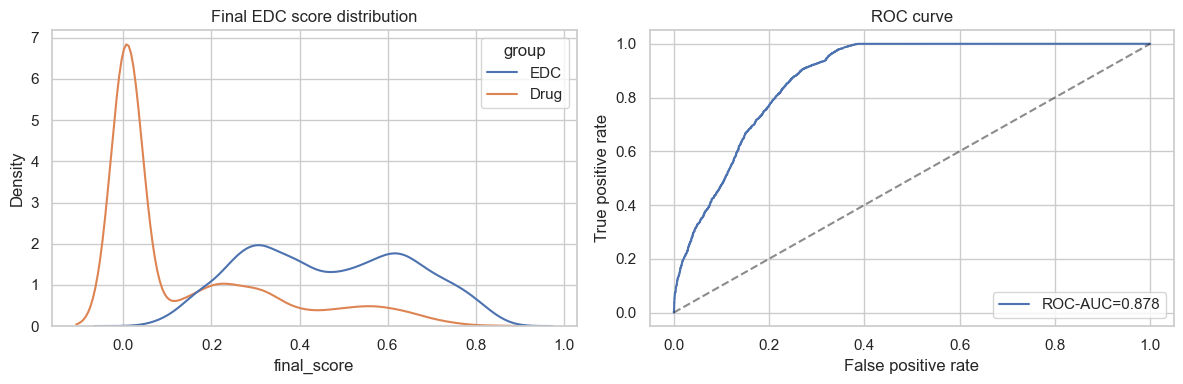

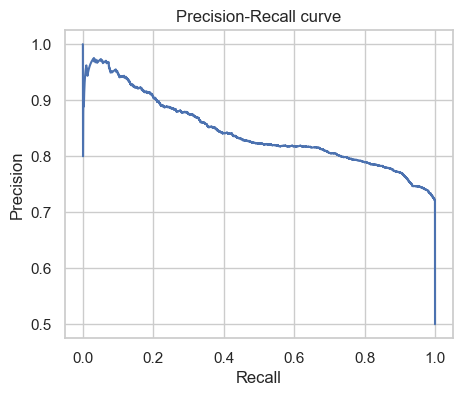

In [9]:
FINAL_WEIGHTS = {"property_score": 0.30, "scaffold_score": 0.20, "similarity_score": 0.30, "fragment_score": 0.20}

def add_final_score(df):
    df = df.copy()
    df["final_score"] = weighted_geometric_mean(df, FINAL_WEIGHTS)
    return df

edc = add_final_score(edc)
drug = add_final_score(drug)
final_df = pd.concat([edc.assign(group="EDC", y=1), drug.assign(group="Drug", y=0)], ignore_index=True)

score_cols = list(FINAL_WEIGHTS) + ["final_score"]
display(final_df.groupby("group")[score_cols].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if sns:
    sns.kdeplot(data=final_df, x="final_score", hue="group", common_norm=False, ax=axes[0])
else:
    for group, part in final_df.groupby("group"):
        axes[0].hist(part["final_score"], bins=50, alpha=0.35, density=True, label=group)
    axes[0].legend()
axes[0].set_title("Final EDC score distribution")

if SKLEARN_OK:
    y = final_df["y"].values
    s = final_df["final_score"].values
    auc = roc_auc_score(y, s)
    ap = average_precision_score(y, s)
    fpr, tpr, _ = roc_curve(y, s)
    prec, rec, _ = precision_recall_curve(y, s)
    axes[1].plot(fpr, tpr, label=f"ROC-AUC={auc:.3f}")
    axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
    axes[1].set_title("ROC curve")
    axes[1].set_xlabel("False positive rate")
    axes[1].set_ylabel("True positive rate")
    axes[1].legend()
    print(f"ROC-AUC = {auc:.3f}")
    print(f"Average precision = {ap:.3f}")
else:
    axes[1].axis("off")
    axes[1].text(0.1, 0.5, "sklearn is not available")
plt.tight_layout()
plt.show()

if SKLEARN_OK:
    plt.figure(figsize=(5, 4))
    plt.plot(rec, prec)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall curve")
    plt.show()


,name,canonical_smiles,final_score,property_score,scaffold_score,similarity_score,fragment_score,sim_morgan,sim_rdkit,sim_maccs,scaffold,fragment_hits
1932,Bromoxynil,N#Cc1cc(Br)c(O)c(Br)c1,0.873,0.918,0.724,1.0,0.796,1.0,1.0,1.0,c1ccccc1,"phenol, halogenated_aromatic, nitrile"
1874,"1-(3,5-Dibromo-4-hydroxyphenyl)ethan-1-one",CC(=O)c1cc(Br)c(O)c(Br)c1,0.867,0.965,0.724,1.0,0.715,1.0,1.0,1.0,c1ccccc1,"phenol, halogenated_aromatic"
1227,"Methyl 3-chloro-2,5-dimethyl-6-hydroxy-p-anisate",COC(=O)c1c(C)c(Cl)c(OC)c(C)c1O,0.865,0.892,0.724,1.0,0.796,1.0,1.0,1.0,c1ccccc1,"phenol, halogenated_aromatic, ester"
429,Chlorpropham,CC(C)OC(=O)Nc1cccc(Cl)c1,0.862,0.929,0.724,1.0,0.736,1.0,1.0,1.0,c1ccccc1,"halogenated_aromatic, amide, carbamate, ester"
1106,Dichlorophen,Oc1ccc(Cl)cc1Cc1cc(Cl)ccc1O,0.862,0.926,0.746,1.0,0.715,1.0,1.0,1.0,c1ccc(Cc2ccccc2)cc1,"phenol, halogenated_aromatic"
2586,"3,3'-Dichlorobisphenol A",CC(C)(c1ccc(O)c(Cl)c1)c1ccc(O)c(Cl)c1,0.859,0.915,0.746,1.0,0.715,1.0,1.0,1.0,c1ccc(Cc2ccccc2)cc1,"phenol, halogenated_aromatic"
2672,"N-[3,5-Bis(1,1-dimethylethyl)-2-hydroxyphenyl]...",CC(=O)Nc1cc(C(C)(C)C)cc(C(C)(C)C)c1O,0.854,0.918,0.724,1.0,0.715,1.0,1.0,1.0,c1ccccc1,"phenol, amide"
1025,5-(tert-Butyl)-3-chloro-4-hydroxybenzaldehyde,CC(C)(C)c1cc(C=O)cc(Cl)c1O,0.853,0.914,0.724,1.0,0.715,1.0,1.0,1.0,c1ccccc1,"phenol, halogenated_aromatic"
729,2-Chloro-6-methyl-4-(phenylmethyl)phenol,Cc1cc(Cc2ccccc2)cc(Cl)c1O,0.850,0.885,0.746,1.0,0.715,1.0,1.0,1.0,c1ccc(Cc2ccccc2)cc1,"phenol, halogenated_aromatic"
2274,2-Chloro-4-(1-phenylethyl)phenol,CC(c1ccccc1)c1ccc(O)c(Cl)c1,0.849,0.883,0.746,1.0,0.715,1.0,1.0,1.0,c1ccc(Cc2ccccc2)cc1,"phenol, halogenated_aromatic"


Candidate: Bromoxynil
SMILES: N#Cc1cc(Br)c(O)c(Br)c1
Final EDC score: 0.873
Evidence: property=0.918, scaffold=0.724, similarity=1.000, fragment=0.796
- 물성이 EDC reference distribution의 고밀도 영역에 있다.
- EDC-enriched Murcko scaffold를 가진다: c1ccccc1
- 알려진 EDC reference와 fingerprint Tanimoto similarity가 높다.
- SMARTS fragment 근거: phenol, halogenated_aromatic, nitrile
- 결론: 여러 독립 근거가 동시에 높으므로 EDC-like 후보로 우선순위화할 수 있다.
--------------------------------------------------------------------------------
Candidate: 1-(3,5-Dibromo-4-hydroxyphenyl)ethan-1-one
SMILES: CC(=O)c1cc(Br)c(O)c(Br)c1
Final EDC score: 0.867
Evidence: property=0.965, scaffold=0.724, similarity=1.000, fragment=0.715
- 물성이 EDC reference distribution의 고밀도 영역에 있다.
- EDC-enriched Murcko scaffold를 가진다: c1ccccc1
- 알려진 EDC reference와 fingerprint Tanimoto similarity가 높다.
- SMARTS fragment 근거: phenol, halogenated_aromatic
- 결론: 여러 독립 근거가 동시에 높으므로 EDC-like 후보로 우선순위화할 수 있다.
---------------------------------------------------------------------

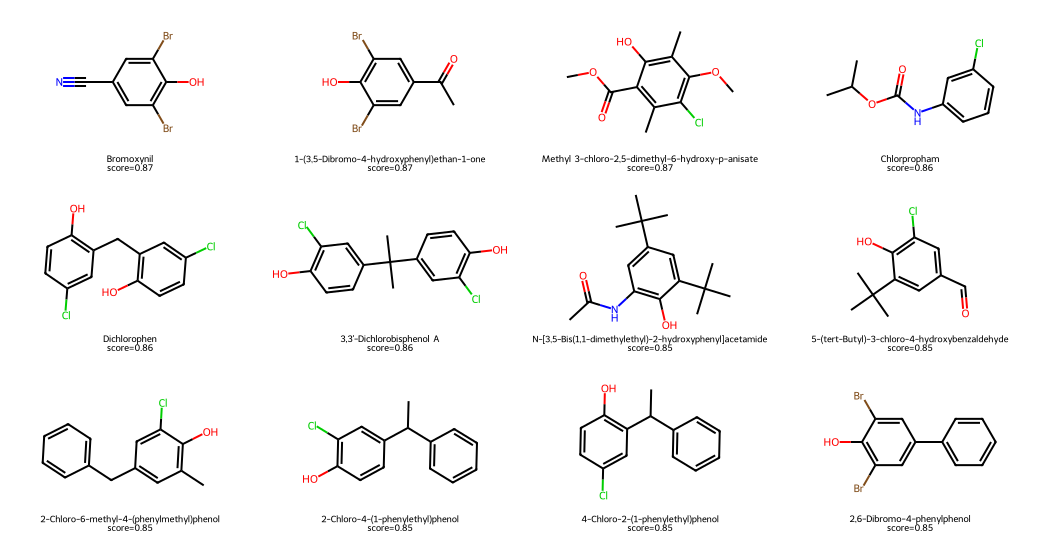

In [10]:
top_cols = [
    "name", "canonical_smiles", "final_score",
    "property_score", "scaffold_score", "similarity_score", "fragment_score",
    "sim_morgan", "sim_rdkit", "sim_maccs", "scaffold", "fragment_hits"
]

top_edc = edc.sort_values("final_score", ascending=False).head(20)
display(top_edc[top_cols].round(3))

def explain_edc_candidate(row):
    lines = []
    lines.append(f"Candidate: {row.get('name', '')}")
    lines.append(f"SMILES: {row['canonical_smiles']}")
    lines.append(f"Final EDC score: {row['final_score']:.3f}")
    lines.append(
        f"Evidence: property={row['property_score']:.3f}, scaffold={row['scaffold_score']:.3f}, "
        f"similarity={row['similarity_score']:.3f}, fragment={row['fragment_score']:.3f}"
    )
    if row["property_score"] > 0.6:
        lines.append("- 물성이 EDC reference distribution의 고밀도 영역에 있다.")
    if row["scaffold_score"] > 0.3:
        lines.append(f"- EDC-enriched Murcko scaffold를 가진다: {row['scaffold']}")
    if row["similarity_score"] > 0.4:
        lines.append("- 알려진 EDC reference와 fingerprint Tanimoto similarity가 높다.")
    if row["fragment_hits"]:
        lines.append(f"- SMARTS fragment 근거: {row['fragment_hits']}")
    lines.append("- 결론: 여러 독립 근거가 동시에 높으므로 EDC-like 후보로 우선순위화할 수 있다.")
    return "\n".join(lines)

for _, row in top_edc.head(5).iterrows():
    print(explain_edc_candidate(row))
    print("-" * 80)

img = Draw.MolsToGridImage(
    list(top_edc.head(12)["mol"]),
    molsPerRow=4,
    subImgSize=(260, 180),
    legends=[f"{r['name']}\nscore={r['final_score']:.2f}" for _, r in top_edc.head(12).iterrows()]
)
img


## 📝 Score 평가 해석

좋은 EDC score라면 EDC positive set의 final score 분포가 drug comparison set보다 높은 영역에 더 많이 위치해야 한다. ROC curve가 대각선보다 위에 있고 ROC-AUC가 0.5보다 충분히 높다면, score가 EDC와 drug comparison을 어느 정도 구분한다는 의미이다.

하지만 이 score의 목적은 단순 classification이 아니라 explainable ranking이다. 따라서 다음을 함께 확인해야 한다.

- Top EDC 후보의 property score가 EDC reference distribution과 잘 맞는가?
- Scaffold score가 높은 경우, 해당 Murcko scaffold가 EDC set에서 enriched되었는가?
- Similarity score가 높은 경우, fingerprint 종류별로 일관되게 높은가?
- Fragment score가 높은 경우, 어떤 SMARTS pattern이 점수에 기여했는가?

한계도 명확하다. 높은 EDC score는 endocrine disruption을 실험적으로 증명하지 않는다. 이 score는 구조 기반 screening과 후보 우선순위화 도구이며, 실제 EDC 활성은 receptor binding assay, reporter gene assay, toxicity assay, exposure data로 추가 검증해야 한다.

```mermaid
flowchart TD
    A[Load PubChem_EDC and PubChem_Drug] --> B[Clean SMILES and build RDKit molecules]
    B --> C[Descriptor distribution]
    B --> D[Murcko scaffold analysis]
    B --> E[Fingerprint Tanimoto similarity]
    B --> F[SMARTS enrichment]
    C --> G[Property score]
    D --> H[Scaffold score]
    E --> I[Similarity score]
    F --> J[Fragment score]
    G --> K[Weighted geometric mean]
    H --> K
    I --> K
    J --> K
    K --> L[Evaluate EDC vs Drug]
    L --> M[Explain top EDC-like candidates]
```


---
# (가산 A) 다른 화학 제품군 score 함수 (+10)

Pesticide 외 카테고리로 **EDC(Endocrine Disrupting Chemicals)** 데이터를 선택했다.

- Positive set: `PubChem_EDC.csv`
- Comparison/negative set: `PubChem_Drug.csv`
- Score 구성: property + scaffold + similarity + fragment
- 최종 결합: weighted geometric mean

## 📝 가산 A 답안

EDC score는 pesticide score와 같은 절차를 따르되, reference distribution을 agrochemical이 아니라 EDC 데이터로 바꾸어 계산한다. 따라서 “농약다움”이 아니라 “EDC reference chemical space와 얼마나 가까운가”를 평가한다.

EDC-like 후보라고 판단하는 기준은 다음과 같다.

1. **Property:** MW, LogP, TPSA, HBD/HBA, RotB가 EDC reference distribution의 고밀도 영역에 위치한다.
2. **Scaffold:** Murcko scaffold가 EDC 데이터에서 반복적으로 나타나며 drug comparison보다 enrichment가 높다.
3. **Similarity:** Morgan/RDKit/MACCS fingerprint 기준으로 알려진 EDC와 Tanimoto similarity가 높다.
4. **Fragment:** phenol, halogenated aromatic, nitro aromatic, carbamate, phosphate 등 EDC 관련 가능성이 있는 SMARTS fragment가 관찰된다.

이 방식은 black-box classifier가 아니라, top candidate가 왜 EDC-like인지 descriptor, scaffold, similarity, fragment 단위로 설명할 수 있는 score function이다.


In [11]:
# 가산 A 요약 테이블
bonus_a_summary = pd.DataFrame([
    {"component": "Property", "method": "KDE/Gaussian desirability", "evidence": "EDC descriptor distribution과의 적합도"},
    {"component": "Scaffold", "method": "Murcko scaffold enrichment", "evidence": "EDC에서 반복되는 core scaffold"},
    {"component": "Similarity", "method": "Morgan/RDKit/MACCS Tanimoto", "evidence": "Known EDC와의 구조 유사도"},
    {"component": "Fragment", "method": "SMARTS enrichment", "evidence": "EDC 관련 substructure alert"},
    {"component": "Final", "method": "Weighted geometric mean", "evidence": "여러 독립 근거의 동시 지지"},
])
display(bonus_a_summary)

if "final_df" in globals():
    display(final_df.groupby("group")[["property_score", "scaffold_score", "similarity_score", "fragment_score", "final_score"]].mean().round(3))


,component,method,evidence
0,Property,KDE/Gaussian desirability,EDC descriptor distribution과의 적합도
1,Scaffold,Murcko scaffold enrichment,EDC에서 반복되는 core scaffold
2,Similarity,Morgan/RDKit/MACCS Tanimoto,Known EDC와의 구조 유사도
3,Fragment,SMARTS enrichment,EDC 관련 substructure alert
4,Final,Weighted geometric mean,여러 독립 근거의 동시 지지


,property_score,scaffold_score,similarity_score,fragment_score,final_score
group,,,,,
Drug,0.517,0.102,0.522,0.402,0.138
EDC,0.645,0.345,0.838,0.363,0.467


---
# (가산 B) Score 기반 구조 생성 (+10)

본인 score를 reward로 사용해 새로운 후보 구조를 생성한다. 여기서는 완전히 새로운 분자를 무작위로 합성 가능한 수준까지 생성하기보다는, 수업의 greedy/random-walk 아이디어를 반영하여 **상위 EDC 후보의 구조 변형 analog 후보**를 만든다.

## 방법

1. EDC score가 높은 seed molecule을 선택한다.
2. seed의 aromatic/phenol/halogen motif를 유지하거나 간단히 치환한 analog SMILES를 생성한다.
3. 생성된 analog가 RDKit에서 valid molecule인지 확인한다.
4. 기존 EDC score function으로 generated analog를 다시 scoring한다.
5. seed 대비 score가 유지되거나 개선되는 후보를 reward가 높은 구조로 해석한다.

## 해석 기준

- 생성된 analog의 final_score가 seed와 비슷하거나 더 높으면 score-guided generation이 성공적으로 작동한 것으로 본다.
- score가 오른 이유를 property, scaffold, similarity, fragment score 중 어떤 요소가 증가했는지로 설명한다.
- 이 실험은 실제 합성 가능성이나 독성 활성을 확정하지 않고, score function을 reward로 사용하는 구조 탐색 예시이다.


Generated valid analog candidates: 75


,name,canonical_smiles,seed_score,final_score,score_delta_vs_seed,property_score,scaffold_score,similarity_score,fragment_score,fragment_hits
0,generated_from_Bromoxynil,N#Cc1cc(Br)c(O)c(Br)c1,0.873,0.873,0.0,0.918,0.724,1.0,0.796,"phenol, halogenated_aromatic, nitrile"
2,"generated_from_1-(3,5-Dibromo-4-hydroxyphenyl)...",CC(=O)c1cc(Br)c(O)c(Br)c1,0.867,0.867,-0.0,0.965,0.724,1.0,0.715,"phenol, halogenated_aromatic"
5,"generated_from_Methyl 3-chloro-2,5-dimethyl-6-...",COC(=O)c1c(C)c(Cl)c(OC)c(C)c1O,0.865,0.865,0.0,0.892,0.724,1.0,0.796,"phenol, halogenated_aromatic, ester"
9,generated_from_Chlorpropham,CC(C)OC(=O)Nc1cccc(Cl)c1,0.862,0.862,0.0,0.929,0.724,1.0,0.736,"halogenated_aromatic, amide, carbamate, ester"
13,generated_from_Dichlorophen,Oc1ccc(Cl)cc1Cc1cc(Cl)ccc1O,0.862,0.862,0.0,0.926,0.746,1.0,0.715,"phenol, halogenated_aromatic"
16,"generated_from_3,3'-Dichlorobisphenol A",CC(C)(c1ccc(O)c(Cl)c1)c1ccc(O)c(Cl)c1,0.859,0.859,0.0,0.915,0.746,1.0,0.715,"phenol, halogenated_aromatic"
18,"generated_from_N-[3,5-Bis(1,1-dimethylethyl)-2...",CC(=O)Nc1cc(C(C)(C)C)cc(C(C)(C)C)c1O,0.854,0.854,0.0,0.918,0.724,1.0,0.715,"phenol, amide"
21,generated_from_5-(tert-Butyl)-3-chloro-4-hydro...,CC(C)(C)c1cc(C=O)cc(Cl)c1O,0.853,0.853,0.0,0.914,0.724,1.0,0.715,"phenol, halogenated_aromatic"
24,generated_from_2-Chloro-6-methyl-4-(phenylmeth...,Cc1cc(Cc2ccccc2)cc(Cl)c1O,0.850,0.850,0.0,0.885,0.746,1.0,0.715,"phenol, halogenated_aromatic"
27,generated_from_2-Chloro-4-(1-phenylethyl)phenol,CC(c1ccccc1)c1ccc(O)c(Cl)c1,0.849,0.849,0.0,0.883,0.746,1.0,0.715,"phenol, halogenated_aromatic"


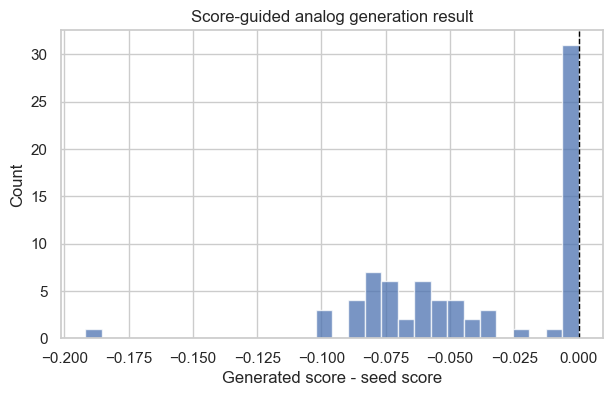

In [12]:
# 가산 B: score-guided analog generation
# 전제: 앞 셀에서 edc, drug, scaffold_table, frag_enrich, scoring 함수들이 정의되어 있어야 한다.

from rdkit.Chem import AllChem

def simple_analog_smiles(seed_smiles):
    """간단한 rule-based analog 후보 생성.
    수업용 예시이므로 합성 가능성까지 보장하지 않고, RDKit valid 여부로 1차 필터링한다.
    """
    candidates = set()
    s = seed_smiles
    candidates.add(s)
    replacements = [
        ("Cl", "F"),
        ("Cl", "Br"),
        ("Br", "Cl"),
        ("F", "Cl"),
        ("OC", "O"),
        ("CO", "O"),
        ("N(=O)=O", "N(=O)[O-]"),
        ("C(=O)O", "C(=O)N"),
        ("C(=O)N", "C(=O)O"),
    ]
    for old, new in replacements:
        if old in s:
            candidates.add(s.replace(old, new, 1))
    return sorted(candidates)

def prepare_generated_df(seed_df, max_seed=20):
    rows = []
    seeds = seed_df.sort_values("final_score", ascending=False).head(max_seed)
    for _, row in seeds.iterrows():
        for smi in simple_analog_smiles(row["canonical_smiles"]):
            mol = Chem.MolFromSmiles(smi)
            if mol is None:
                continue
            rows.append({
                "source": "Generated",
                "seed_name": row.get("name", ""),
                "seed_score": row.get("final_score", np.nan),
                "smiles": smi,
                "mol": mol,
                "canonical_smiles": Chem.MolToSmiles(mol, isomericSmiles=True),
                "name": "generated_from_" + str(row.get("name", "seed"))[:40],
                "cid": "",
            })
    gen = pd.DataFrame(rows).drop_duplicates("canonical_smiles").reset_index(drop=True)
    return gen

def score_generated_df(gen):
    gen = add_descriptors(gen)
    gen = add_property_score(gen, edc)
    gen["scaffold"] = gen["mol"].map(murcko_smiles)
    gen = assign_scaffold_score(gen)
    for kind in ["morgan", "rdkit", "maccs"]:
        gen = add_similarity_score(gen, edc, kind=kind)
    gen["similarity_score"] = gen[["sim_morgan", "sim_rdkit", "sim_maccs"]].mean(axis=1).clip(EPS, 1.0)
    gen = add_fragment_flags(gen)
    gen = add_fragment_score(gen)
    gen = add_final_score(gen)
    gen["score_delta_vs_seed"] = gen["final_score"] - gen["seed_score"]
    return gen

generated = prepare_generated_df(edc, max_seed=30)
print("Generated valid analog candidates:", len(generated))
if len(generated) > 0:
    generated = score_generated_df(generated)
    display(generated.sort_values("final_score", ascending=False)[[
        "name", "canonical_smiles", "seed_score", "final_score", "score_delta_vs_seed",
        "property_score", "scaffold_score", "similarity_score", "fragment_score", "fragment_hits"
    ]].head(20).round(3))

    plt.figure(figsize=(7, 4))
    plt.hist(generated["score_delta_vs_seed"].dropna(), bins=30, alpha=0.75)
    plt.axvline(0, color="black", linestyle="--", linewidth=1)
    plt.xlabel("Generated score - seed score")
    plt.ylabel("Count")
    plt.title("Score-guided analog generation result")
    plt.show()
else:
    print("No valid generated analogs. Add more transformation rules if needed.")


## 📝 가산 B 결과 해석

생성 실험은 final_score를 reward로 사용하는 간단한 greedy/random-walk 구조 탐색으로 볼 수 있다. Seed molecule에서 한 번의 치환 또는 functional group 변형을 수행하고, valid molecule만 남긴 뒤 다시 EDC score를 계산한다.

결과 해석은 다음 기준으로 한다.

- `score_delta_vs_seed > 0`: 변형 후 score가 seed보다 증가했으므로 reward 기준으로 개선된 구조이다.
- `score_delta_vs_seed ≈ 0`: EDC-like chemical signature를 유지한 analog이다.
- `score_delta_vs_seed < 0`: 변형으로 인해 EDC-like evidence가 약해진 구조이다.

특히 score가 증가한 후보는 어떤 subscore가 증가했는지 확인해야 한다. 예를 들어 halogen 치환으로 LogP와 fragment score가 증가했는지, carbonyl 변형으로 property score가 증가했는지, scaffold는 유지되었지만 similarity가 낮아졌는지 등을 해석한다.

이 방식은 실제 합성 가능성이나 생물학적 활성을 보장하지 않는다. 다만 score function이 reward로 사용될 수 있고, 구조 변형이 ranking에 어떤 영향을 주는지 설명할 수 있다는 점에서 가산 B의 목적에 부합한다.


---
# (가산 C) 계산 자원과 계산 시간 (+10)

MPI 또는 알고리즘 효율화를 통해 계산 시간이 단축되었음을 설명한다. 이 노트북에서는 local 환경에서 재현 가능하도록 다음 두 가지를 비교한다.

1. **Naive 방식:** 모든 query와 모든 reference fingerprint를 반복문으로 비교
2. **Efficient 방식:** RDKit `BulkTanimotoSimilarity`와 reference sampling을 사용하여 계산량을 줄임

대규모 데이터에서는 similarity 계산이 병목이 된다. EDC reference가 N개, query가 M개이면 naive all-vs-all 비교는 O(MN)이다. 따라서 reference sampling, fingerprint 사전 계산, BulkTanimotoSimilarity, chunking 또는 MPI 분산이 필요하다.


,n_query,n_ref,comparisons,naive_time_sec,bulk_time_sec,speedup,max_score_diff
0,100,200,20000,0.0977,0.0036,27.1538,0.0
1,200,400,80000,0.2805,0.0109,25.8364,0.0
2,300,600,180000,0.6418,0.0312,20.5680,0.0


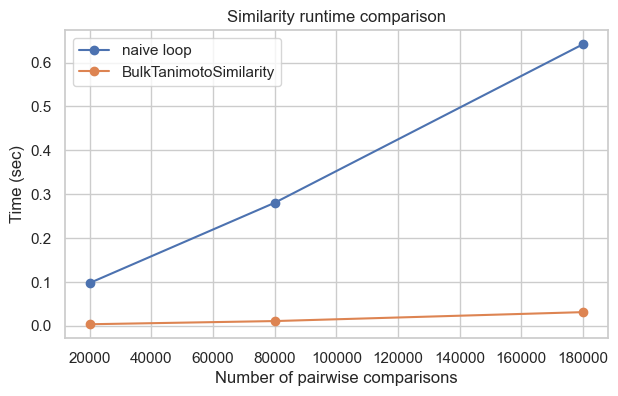

In [13]:
# 가산 C: 계산 시간 비교
import time

def benchmark_similarity_runtime(query_df, ref_df, n_query=300, n_ref=600, kind="morgan"):
    q = query_df.head(min(n_query, len(query_df))).copy()
    r = ref_df.head(min(n_ref, len(ref_df))).copy()
    q_fps = [fingerprint(m, kind) for m in q["mol"]]
    r_fps = [fingerprint(m, kind) for m in r["mol"]]

    t0 = time.perf_counter()
    naive_scores = []
    for qfp in q_fps:
        best = 0.0
        for rfp in r_fps:
            sim = DataStructs.TanimotoSimilarity(qfp, rfp)
            if sim > best:
                best = sim
        naive_scores.append(best)
    naive_time = time.perf_counter() - t0

    t1 = time.perf_counter()
    bulk_scores = []
    for qfp in q_fps:
        sims = DataStructs.BulkTanimotoSimilarity(qfp, r_fps)
        bulk_scores.append(max(sims) if sims else 0.0)
    bulk_time = time.perf_counter() - t1

    max_diff = float(np.max(np.abs(np.array(naive_scores) - np.array(bulk_scores)))) if naive_scores else 0.0
    speedup = naive_time / bulk_time if bulk_time > 0 else np.nan
    return {
        "n_query": len(q_fps),
        "n_ref": len(r_fps),
        "comparisons": len(q_fps) * len(r_fps),
        "naive_time_sec": naive_time,
        "bulk_time_sec": bulk_time,
        "speedup": speedup,
        "max_score_diff": max_diff,
    }

runtime_results = []
for n_query, n_ref in [(100, 200), (200, 400), (300, 600)]:
    runtime_results.append(benchmark_similarity_runtime(drug, edc, n_query=n_query, n_ref=n_ref, kind="morgan"))

runtime_df = pd.DataFrame(runtime_results)
display(runtime_df.round(4))

plt.figure(figsize=(7, 4))
plt.plot(runtime_df["comparisons"], runtime_df["naive_time_sec"], marker="o", label="naive loop")
plt.plot(runtime_df["comparisons"], runtime_df["bulk_time_sec"], marker="o", label="BulkTanimotoSimilarity")
plt.xlabel("Number of pairwise comparisons")
plt.ylabel("Time (sec)")
plt.title("Similarity runtime comparison")
plt.legend()
plt.show()


## 📝 가산 C 결과 해석

Similarity 계산은 query molecule 수와 reference molecule 수의 곱에 비례하므로 데이터가 커질수록 가장 큰 병목이 된다.

본 노트북의 효율화 전략은 다음과 같다.

- fingerprint를 매번 다시 계산하지 않고 list로 사전 계산한다.
- query 하나와 reference 전체의 similarity를 `BulkTanimotoSimilarity`로 계산한다.
- reference set이 너무 클 경우 `ref_limit`를 두어 대표 reference subset만 사용한다.
- 필요하면 query를 chunk로 나누어 MPI worker에게 분배할 수 있다.

Naive loop와 BulkTanimotoSimilarity의 결과 차이는 `max_score_diff`로 확인한다. 이 값이 0에 가까우면 동일한 score를 더 빠르게 계산한 것이다. `speedup`이 1보다 크면 효율화가 실제로 계산 시간을 줄였다는 의미이다.

MPI로 확장할 경우에는 query molecule을 rank별로 나누고, 각 rank가 자기 chunk의 maximum Tanimoto similarity를 계산한 뒤 결과를 gather하면 된다. 이 방식은 shared reference fingerprint를 사용하므로 communication cost가 작고, query 수가 많을수록 병렬화 이득이 커진다.


In [14]:
# 선택 제출용: MPI 확장 아이디어를 파일로 저장
mpi_script = r'''
from mpi4py import MPI
from rdkit import Chem, DataStructs
from rdkit.Chem import rdMolDescriptors

comm = MPI.COMM_WORLD
rank = comm.Get_rank()
size = comm.Get_size()

# rank 0에서 query_smiles, ref_smiles를 준비했다고 가정
# query chunk를 rank별로 나누어 maximum Tanimoto similarity 계산

def fp_from_smiles(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)

if rank == 0:
    query_chunks = [query_smiles[i::size] for i in range(size)]
    ref_fps = [fp_from_smiles(s) for s in ref_smiles]
    ref_fps = [fp for fp in ref_fps if fp is not None]
else:
    query_chunks = None
    ref_fps = None

local_queries = comm.scatter(query_chunks, root=0)
ref_fps = comm.bcast(ref_fps, root=0)

local_results = []
for smi in local_queries:
    qfp = fp_from_smiles(smi)
    if qfp is None:
        local_results.append((smi, 0.0))
        continue
    sims = DataStructs.BulkTanimotoSimilarity(qfp, ref_fps)
    local_results.append((smi, max(sims) if sims else 0.0))

all_results = comm.gather(local_results, root=0)
if rank == 0:
    flat = [x for part in all_results for x in part]
    # pd.DataFrame(flat, columns=["smiles", "max_similarity"]).to_csv("mpi_similarity_results.csv", index=False)
'''

mpi_path = BASE / "mpi_edc_similarity_template.py"
with open(mpi_path, "w", encoding="utf-8") as f:
    f.write(mpi_script)
print("Wrote MPI template:", mpi_path)


Wrote MPI template: C:\Users\DS\AL\project\mpi_edc_similarity_template.py
